# LendMind

### 1) Importing Libraries

In [ ]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install matplotlib==3.9.3

In [3]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### 2) Read & Understand The Data

In [4]:
all_data = pd.read_csv(r"..\DataSet\archive\loan.csv")

In [5]:
all_data.shape

(2260668, 145)

A) We will take a random sample from the dataset (all_data), for example 5% of the total dataset:

no of rows = 0.05 * 2260668 = 113,033 rows

--> a)

In [6]:
all_data = all_data[all_data['loan_status'].isin(['Fully Paid', 'Charged Off'])]
all_data['loan_status'] = all_data['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})
all_data.shape

(1303607, 145)

--> b)

In [7]:
df = all_data.sample(frac= 0.05, random_state= 42)
df.shape

(65180, 145)

In [8]:
df.sample(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
1122328,NaN,NaN,6000,6000,6000.0,36 months,7.26,185.98,A,A4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2015214,NaN,NaN,26000,26000,26000.0,60 months,18.24,663.63,D,D5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2069168,NaN,NaN,13375,13375,13375.0,36 months,12.99,450.60,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
852697,NaN,NaN,5000,5000,5000.0,36 months,7.99,156.66,A,A5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1175429,NaN,NaN,24000,24000,24000.0,36 months,12.29,800.48,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


B) dealing with Null values

In [9]:
df = df.loc[:, df.isnull().mean()<0.4]
df.shape

(65180, 87)

In [10]:
df.sample(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
1188338,18000,18000,18000.0,36 months,7.89,563.15,A,A5,IT Systems Support,10+ years,...,0.0,0.0,0.0,252233.0,207745.0,20500.0,226233.0,N,Cash,N
1822472,10000,10000,10000.0,36 months,20.49,374.14,E,E1,88 International,2 years,...,100.0,0.0,0.0,28572.0,23345.0,9900.0,17872.0,N,Cash,N
2017478,5000,5000,5000.0,36 months,10.15,161.69,B,B2,Security,10+ years,...,100.0,1.0,0.0,19521.0,5451.0,1500.0,13121.0,N,Cash,N
1211912,25000,25000,25000.0,60 months,9.17,521.03,B,B2,Sales,2 years,...,100.0,0.0,0.0,288140.0,93121.0,21000.0,85540.0,N,Cash,Y
938199,25000,25000,24850.0,36 months,16.99,891.20,D,D3,Treasury Representative,8 years,...,0.0,0.0,0.0,38676.0,21472.0,6900.0,30516.0,N,Cash,N


C) Remove columns where all cells have the same value (Zero Variance Filter)

In [11]:
df = df.loc[:, df.nunique()>1]
df.shape

(65180, 82)

In [12]:
df.sample(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag
951212,24000,24000,23925.0,36 months,8.38,756.29,B,B1,Sr Solution Architect,1 year,...,100.0,100.0,0.0,3.0,527837.0,92221.0,29600.0,105937.0,Cash,N
1309423,5950,5950,5950.0,36 months,9.49,190.57,B,B2,Associate Director of Enrollment,2 years,...,100.0,0.0,1.0,0.0,93629.0,82095.0,7800.0,81529.0,Cash,N
1156689,18000,18000,18000.0,36 months,11.53,593.83,B,B5,Installer,3 years,...,84.6,100.0,0.0,0.0,175197.0,29293.0,11700.0,38197.0,Cash,N
865171,7000,7000,6950.0,36 months,16.99,249.54,D,D1,nurse Assistant,3 years,...,96.7,0.0,0.0,0.0,40565.0,24934.0,6800.0,19665.0,Cash,N
1375824,40000,40000,40000.0,60 months,11.39,877.50,B,B3,Nurse Anesthetist,9 years,...,100.0,57.1,0.0,0.0,397801.0,117610.0,85700.0,92476.0,Cash,N


D) High Cardinality Filter

In [13]:
string_columns = df.select_dtypes(include='object').columns
string_df = df[string_columns]
hated_columns = string_df.loc[:, (string_df.nunique() > 50)].columns
df = df.drop(columns=hated_columns)
df.shape

(65180, 75)

E) Multicollinearity Filter

In [14]:
corr_matrix = df.select_dtypes(include=['number']).corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]
df = df.drop(columns=to_drop)
df.shape

(65180, 66)

['recoveries', 'last_pymnt_amnt', 'total_pymnt', 'loan_amnt', 'debt_settlement_flag_Y', 'int_rate', 'total_rec_int', 'term_ 60 months', 'total_rec_late_fee', 'dti', 'bc_open_to_buy', 'revol_bal', 'annual_inc', 'avg_cur_bal', 'tot_cur_bal']


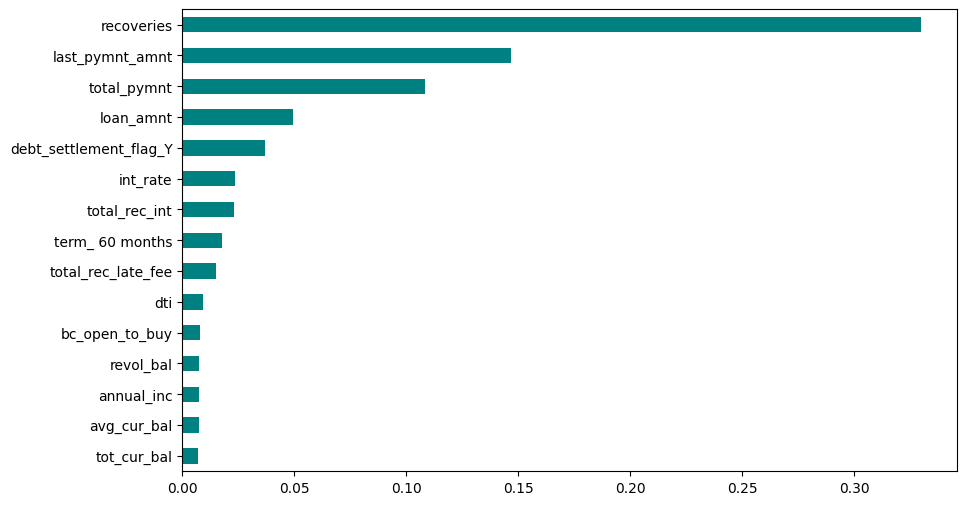

In [ ]:
"""
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

X = df.drop(columns=['loan_status'])
y = df['loan_status']
X_encoded = pd.get_dummies(X, drop_first=True)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_encoded, y)

importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
top_15_features = importances.sort_values(ascending=False).head(15).index.tolist()

print(top_15_features)

plt.figure(figsize=(10, 6))
importances.sort_values(ascending=False).head(15).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.show()
"""

F) Preventing Data Leakage

In [ ]:
leakage_columns = [
    'recoveries', 'collection_recovery_fee', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'last_pymnt_amnt',
    'out_prncp', 'out_prncp_inv', 'debt_settlement_flag' 
]

cols_to_drop = [col for col in leakage_columns if col in df.columns]
df_safe = df.drop(columns=cols_to_drop)

In [21]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X = df_safe.drop(columns=['loan_status'])
y = df_safe['loan_status']
X_encoded = pd.get_dummies(X, drop_first=True).fillna(-999)


rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_encoded, y)

importances = pd.Series(rf_selector.feature_importances_, index=X_encoded.columns)
top_15_features = importances.sort_values(ascending=False).head(15).index.tolist()

df_final = X_encoded[top_15_features].copy()
df_final['loan_status'] = y

print("✅ The top 15 columns were successfully extracted, and they are:")
for i, feature in enumerate(top_15_features, 1):
    print(f"{i}- {feature}")

print("-" * 40)
print("Final data size (15 features + 1 goal):", df_final.shape)

✅ The top 15 columns were successfully extracted, and they are:
1- int_rate
2- dti
3- annual_inc
4- loan_amnt
5- revol_util
6- mo_sin_old_rev_tl_op
7- revol_bal
8- avg_cur_bal
9- bc_open_to_buy
10- bc_util
11- tot_cur_bal
12- total_bc_limit
13- total_bal_ex_mort
14- mo_sin_old_il_acct
15- total_rev_hi_lim
----------------------------------------
Final data size (15 features + 1 goal): (65180, 16)


In [29]:
df_final.to_csv(r'..\DataSet\cleaned_data.csv', index=False)
print("Cleaned data successfully saved!")

Cleaned data successfully saved!
